**EDA INTRODUCTION**


We begin by loading the cleaned dataset and inspecting the first few rows.
This allows us to confirm the structure of the data, check variable names, and ensure the cleaning script produced a tidy dataset suitable for analysis.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.8)

# Project directory
project_dir = Path("..").resolve()

# Path to your merged dataset (the one with petrol, rainfall, patronage, etc.)
data_path = project_dir / "data" / "clean" / "merged_final.csv"

# Output folder
output_dir = project_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)


In this step, we examine the structure of the dataset using df.info() and df.describe().
The goal is to confirm that the variables have the correct data types, check for missing values, and understand the basic numerical characteristics of each variable.
This helps verify that the cleaning and merging process worked correctly before moving into deeper exploratory analysis.

In [11]:

df = pd.read_csv("data/clean/merged_final.csv")
df.head()

,Year,month,Month name,Metropolitan train,Metropolitan tram,Metropolitan bus,Regional train,Regional coach,Regional bus,PetrolPrice,rainfall_mm,population,public_holiday_count
0,2022,2022-01,January,5778986,5372999,4124071,675856,51750,549859,1.59,79.6,6714248.0,3.0
1,2022,2022-02,February,8382008,7962117,6205045,865020,57210,985731,1.70,6.8,6714248.0,0.0
2,2022,2022-03,March,13045722,11614262,8476974,1298156,73664,1060923,1.88,54.2,6714248.0,1.0
3,2022,2022-04,April,11890697,10065400,6870377,1220454,73735,838558,1.80,72.6,6732148.0,5.0
4,2022,2022-05,May,12833409,10150913,7779324,1288118,71603,1121794,1.93,24.2,6732148.0,0.0


**What do the variables look like?**


The data set contains monthly observations from January 2022 until September 2025. The key variables we look at fall into five main groups of Public Transport, Petrol Price, Rainfall, Population count and Public holiday count.


**Did the data cleaning do anything?**

Yes the data cleaning made a few corrections in the data. Dates were standardised, fixing them to the first day of each month. The population growth count was expanded from quarterly to  monthly, this ensures it aligns with the rest of the dataset which is also monthly. This also prevented a Nan series with missing months. All numeric variables were converted to numeric types to make it easier for our analysis.
The merged dataset now contains a complete and consistent monthly panel with no missing values in key variables. This ensured the data set was ready for explanatory data analysis




##Step 3: Individual Distributions of Each Numeric Variable

In this step, we examine the distribution of each numeric variable separately.
This helps identify skewness, outliers, unusual shapes, and whether any variables may require transformation in later modelling.
Each variable is plotted individually to allow clearer interpretation.

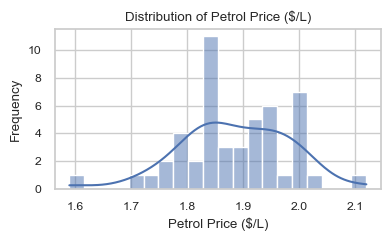

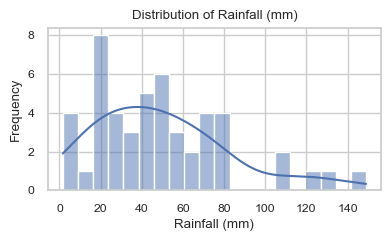

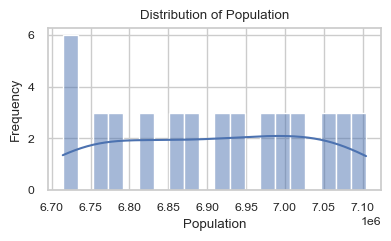

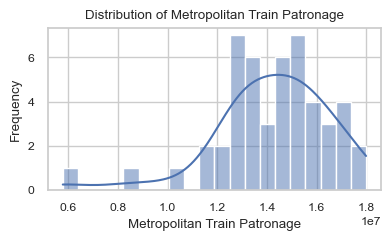

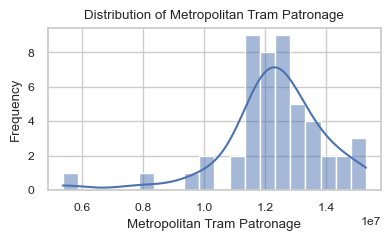

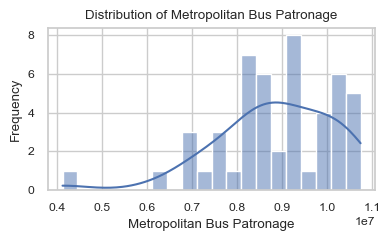

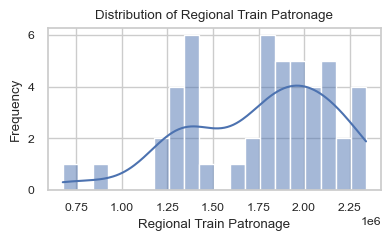

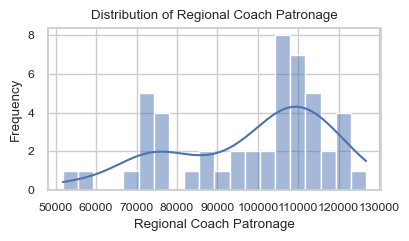

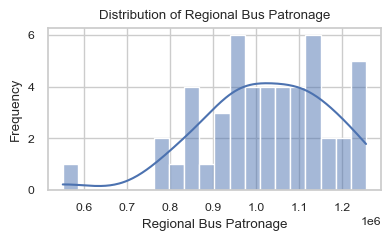

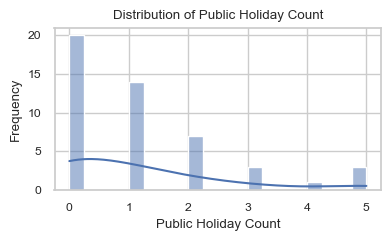

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.8)

numeric_vars = {
    "PetrolPrice": "Petrol Price ($/L)",
    "rainfall_mm": "Rainfall (mm)",
    "population": "Population",
    "Metropolitan train": "Metropolitan Train Patronage",
    "Metropolitan tram": "Metropolitan Tram Patronage",
    "Metropolitan bus": "Metropolitan Bus Patronage",
    "Regional train": "Regional Train Patronage",
    "Regional coach": "Regional Coach Patronage",
    "Regional bus": "Regional Bus Patronage",
    "public_holiday_count": "Public Holiday Count"
}

for var, label in numeric_vars.items():
    plt.figure(figsize=(4, 2.5))
    sns.histplot(df[var], kde=True, bins=20)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


##**Analysis of variable histograms**
**Skewness**
Several variables offer evidence of skewed distribution, though the patterns differ across variables. 

Rainfall has the clearest example of a right skewed distribution. Most months have low to moderate rainfall, while a smaller number of months are experiencing lower rainfall. This is consistent with typical weather patterns and suggests that a few unusually wet months may matter in later analysis. 

Petrol price appears only mildly right skewed. Most observations are concentrated around roughly $1.8 to  $1.96 per litre. There are a few lower and higher priced months, but overall the spread is moderate. This is as expected, since petrol prices vary over time but usually remain within a narrow range. 

Most patronage variables, particularly the metropolitan ones, are somewhat left skewed. The frequencies are generally in the higher range, with a small number of lower demand months. The regional patronage variables show more uneven shapes, particularly regional train and coach. 

Population appears smooth and fairly evenly distributed across its range, which is consistent with a steadily increasing time-series, rather than abrupt month-to-month changes. 

Public holiday count is best interpreted as a discrete variable clustered at low values, rather than a smooth continuous variable.

**Bunching and heaping**
The clearest bunching includes public holiday count, with strong spikes at 0, 1 and 2. This is exactly as expected, since the variable is discrete count and only a small value of numbers are possible every month. 

There is also some evidence of regional bus being tightly clustered around a central range.  This suggests that regional bus demand is relatively stable and does not vary as widely as some of the other patronage measures.

Other continuous variables appear smooth and continuous, without obvious bunching. This is a sign that the cleaned data looks plausible and has not been distorted by coding or formatting.

Bimodality
Most variables appear unimodal, having one main concentration of observations. However, regional train and regional coach patronage appear to show some evidence of bimodality. 

This may suggest busier travel periods and quieter months, possibly linked to seasonality or changing travel conditions. This is a non-standard pattern, and is meaningful, rather than problematic. 

**Spread**
Among the transport variables, metropolitan patronage measures appear to have relatively wide spread, indicating variation in month-to-month demand. 
By contrast, regional bus patronage is more tightly clustered, suggesting more stable use over the same period. This may indicate that demand for regional bus services changes less dramatically across months than demand for some other transport modes.
Population shows relatively little short run variation, compared with other variables. This is as expected for a slowly moving demographic control. 

**Data cleaning check**
Overall, the histograms are consistent with the cleaning steps having been successful. The variables behave in ways that broadly match their real-world meaning:
- petrol prices fall within a plausible range
- rainfall shows a realistic weather-type distribution
- population changes smoothly over time
- patronage variables show meaningful but believable variation
- public holiday count behaves like a discrete calendar variable
There are no obvious impossible values or highly abnormal shapes that would immediately suggest major cleaning errors. Taken together, the distributions suggest that the cleaned dataset is suitable for exploratory analysis and later modelling.


##Scatterplots and Correlation

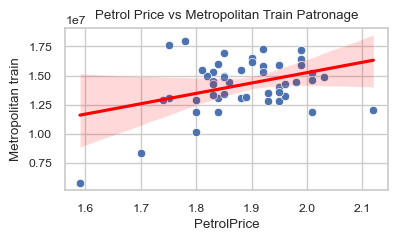

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 2.5))

sns.scatterplot(data=df, x="PetrolPrice", y="Metropolitan train", ax=ax)
sns.regplot(data=df, x="PetrolPrice", y="Metropolitan train", scatter=False, color="red", ax=ax)

ax.set_title("Petrol Price vs Metropolitan Train Patronage")

fig.tight_layout()
plt.show()


**Interpretation**
The scatter plot suggests a positive first-order association between petrol prices and metropolitan train patronage. As petrol prices increase, train usage also tends to rise. This pattern is consistent with a substitution effect, whereby higher fuel costs may make public transport relatively more attractive than private car use.

The relationship appears approximately linear, as indicated by the upward-sloping fitted line. Although the points are somewhat dispersed around the line, there is no obvious curvature or structural break. Therefore, a linear specification appears to be a reasonable starting point for later modelling. There are also no highly extreme outliers that appear likely to dominate the relationship.

For later analysis, this suggests that petrol price is a plausible predictor of metropolitan train patronage. A linear term seems appropriate as an initial specification, and the scatter plot does not suggest an obvious need for transformation for this variable pair. At the same time, this remains a descriptive relationship only, thus further modelling should account for other factors that may also influence patronage.


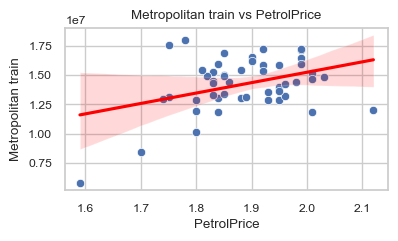

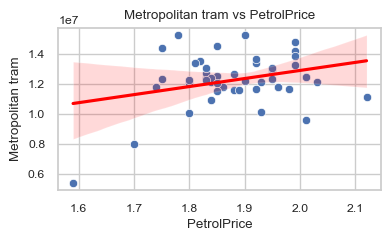

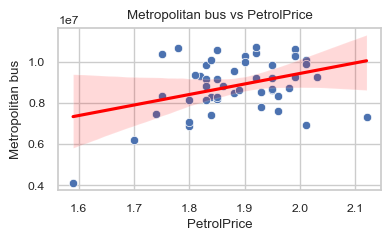

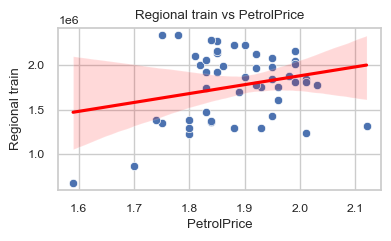

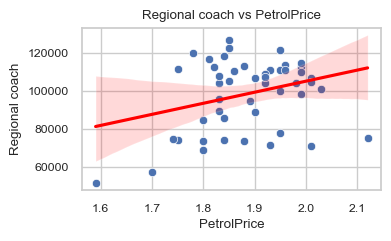

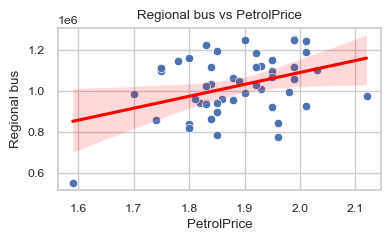

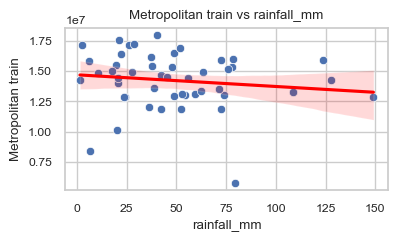

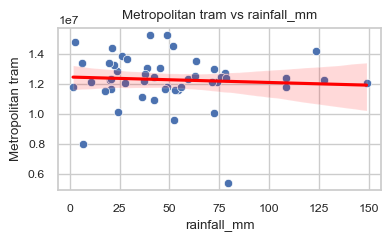

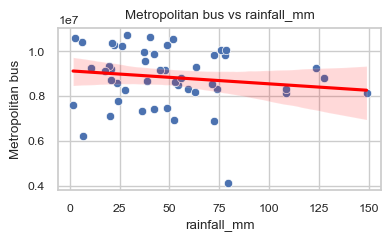

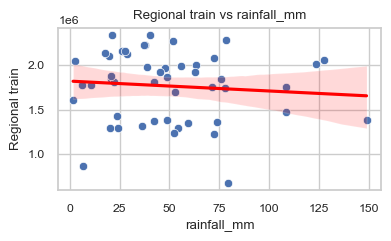

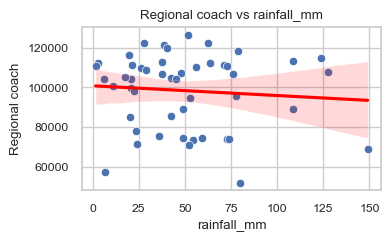

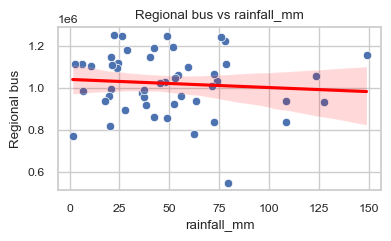

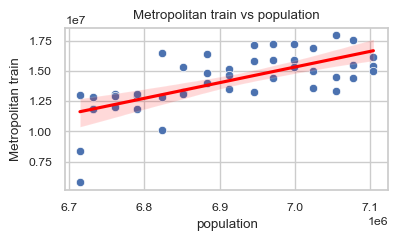

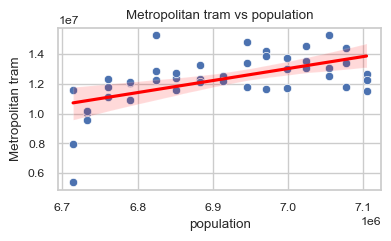

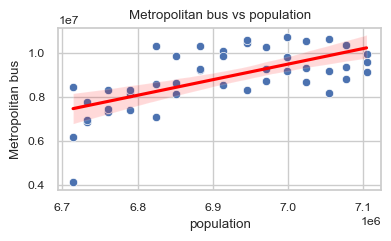

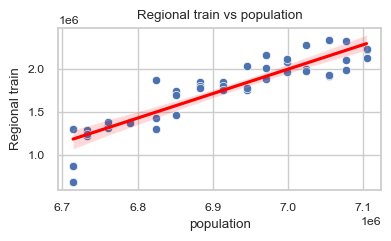

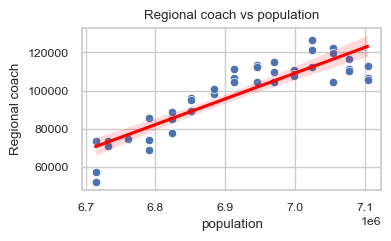

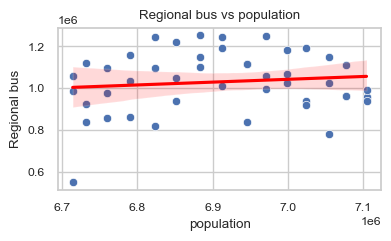

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.8)

df = pd.read_csv("data/clean/merged_final.csv")

predictors = ["PetrolPrice", "rainfall_mm", "population"]
outcomes = [
    "Metropolitan train", "Metropolitan tram", "Metropolitan bus",
    "Regional train", "Regional coach", "Regional bus"
]

for pred in predictors:
    for out in outcomes:
        fig, ax = plt.subplots(figsize=(4, 2.5))
        sns.scatterplot(data=df, x=pred, y=out, ax=ax)
        sns.regplot(data=df, x=pred, y=out, scatter=False, ax=ax, color="red")
        ax.set_title(f"{out} vs {pred}")
        fig.tight_layout()
        plt.show()


##**Exploratory analysis of variable correlation.**
At a descriptive level, patronage tends to move positively with petrol price and population, and weakly negatively with rainfall.

**Petrol price vs patronage**
Across all six patronage measures, the fitted red lines slope upward. This suggests that there is a positive first-order association between petrol prices and public transport usage. This is economically sensible, aligning with the substitution effect: when petrol becomes more expensive, public transport may become relatively more attractive.
The relationship looks moderately positive for the metropolitan modes and still positive yet noisier for the regional modes. The relationship is not especially tight, as the points are still fairly spread out around the line. Thus there is evidence of a first-order association, but it is not extremely strong in these bivariate plots.
Regarding the modelling implication, petrol price appears to be a meaningful predictor. A simple linear term is likely appropriate and there is no transformation needed. However, the positive slope may partially reflect time trends, population growth, post pandemic recovery in transport use, so the relationship is meaningful, but not enough on its own to claim a causal effect.

**Rainfall vs patronage**
Across almost all patronage measures, the fitted lines slope very slightly downwards. This suggests that there is a weak negative association between rainfall and public transport patronage. In the wetter months, patronage appears to be a little lower on average. 
The relationship looks weak, with the slope being rather flat and the cloud of points being broad. Thus, rainfall does not appear to have a large first-order relationship in the data.
The pattern is fairly consistent across metro and regional modes, hence making it worth keeping as a control variable. Despite the effect being small, the consistency suggests it may capture some useful behavioural or seasonal variation. 
A linear specification appears to be a reasonable starting point, and the scatter plots do not suggest an obvious need for transformation at this stage.

**Population vs patronage**
All fitted lines slope upwards, and some of them are quite steep. This suggests a clear positive association between population and public transport patronage. This is exactly as expected: a larger population should generally mean more transport users.
This is the strongest and clearest first-order relationship in the figures, for every mode apart from regional bus. 
This relationship looks much stronger and cleaner than the petrol-price relationship. That implies population is likely to be an important control variable. Population is likely capturing a major structural source of demand. If ignored, the petrol coefficient may be biased because both population and patronage are trending upward over time.
That means its apparent explanatory power may partly reflect shared upward time trends rather than a genuine causal month-to-month effect.
As such, although the relationship is meaningful, it also raises the risk of spurious correlation in a time-series setting.

Shared time trends, omitted variables, and differences across transport modes may all influence the observed relationships, so later modelling should include appropriate controls and consider alternative specifications where necessary.

The scatter plots suggest that a first-order association does exist in the data, but the strength and interpretation of these relationships depend on controlling for broader trends and other confounding factors.


*PATRONAGE DISTRIBUTION BY PUBLIC HOLIDAY COUNT (BOX PLOTS)*

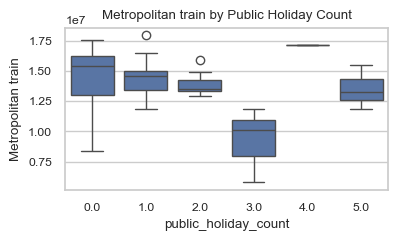

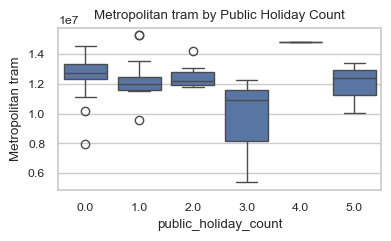

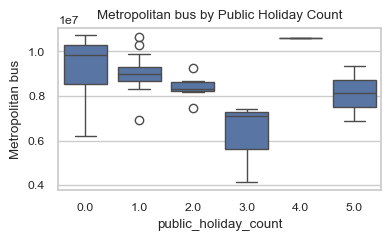

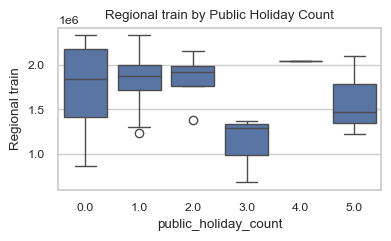

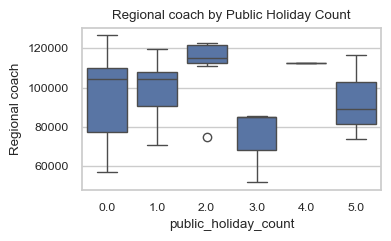

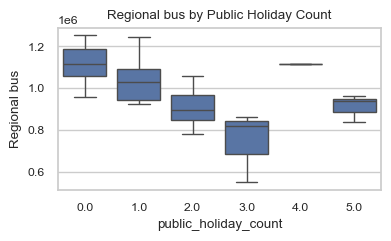

In [15]:
for out in outcomes:
    fig, ax = plt.subplots(figsize=(4, 2.5))
    sns.boxplot(data=df, x="public_holiday_count", y=out, ax=ax)
    ax.set_title(f"{out} by Public Holiday Count")
    fig.tight_layout()
    plt.show()


The boxplots show on average a clear negative first‑order relationship between public holiday count and public transport usage. Patronage is highest when there are 0 holidays, drops sharply from 0 to 1, and then flattens out - a typical pattern for a discrete institutional variable. The effect is strongest for metropolitan modes.

There is a small jump at 5 holidays that differs from the downward pattern, this corresponds to April, which includes Easter and ANZAC Day. April has unique seasonal travel patterns as it is Easter (family visits, weekend trips etc), and because this category has very few observations, its median is unstable. We need to be careful here as this pattern suggests a seasonal artefact, not a true effect of holidays on public transport.

Modelling implications
Public holidays should be included as a control variable to remove predictable calendar‑driven dips in demand. A categorical specification ( 0, 1, 2, 3+) could be safer than a linear term because it avoids over‑interpreting the noisy '5 holidays' category. Correctly specifying this control helps isolate the causal effect of petrol prices by holding holiday‑related variation constant.

In [16]:
corr_vars = [
    "PetrolPrice", "rainfall_mm", "population",
    "Metropolitan train", "Metropolitan tram", "Metropolitan bus",
    "Regional train", "Regional coach", "Regional bus",
    "public_holiday_count"
]

pearson_corr = df[corr_vars].corr(method="pearson")
pearson_corr


,PetrolPrice,rainfall_mm,population,Metropolitan train,Metropolitan tram,Metropolitan bus,Regional train,Regional coach,Regional bus,public_holiday_count
PetrolPrice,1.000000,-0.187561,0.122803,0.378080,0.308593,0.375696,0.249515,0.301228,0.388814,-0.224002
rainfall_mm,-0.187561,1.000000,-0.162787,-0.140455,-0.071087,-0.146354,-0.094587,-0.087977,-0.088442,0.122689
population,0.122803,-0.162787,1.000000,0.680579,0.567258,0.651776,0.911399,0.896275,0.116233,-0.107414
Metropolitan train,0.378080,-0.140455,0.680579,1.000000,0.872032,0.950391,0.887442,0.753338,0.651983,-0.273977
Metropolitan tram,0.308593,-0.071087,0.567258,0.872032,1.000000,0.869778,0.753629,0.671910,0.606218,-0.141987
Metropolitan bus,0.375696,-0.146354,0.651776,0.950391,0.869778,1.000000,0.840852,0.699822,0.767403,-0.366948
Regional train,0.249515,-0.094587,0.911399,0.887442,0.753629,0.840852,1.000000,0.917423,0.392931,-0.208116
Regional coach,0.301228,-0.087977,0.896275,0.753338,0.671910,0.699822,0.917423,1.000000,0.192421,-0.036400
Regional bus,0.388814,-0.088442,0.116233,0.651983,0.606218,0.767403,0.392931,0.192421,1.000000,-0.564958
public_holiday_count,-0.224002,0.122689,-0.107414,-0.273977,-0.141987,-0.366948,-0.208116,-0.036400,-0.564958,1.000000


**Interpretation**
The correlation matrix suggests that petrol price is positively but only moderately correlated with the patronage measures. Coefficients are generally in the range of about 0.25 to 0.39. This indicates that petrol price may be related to public transport usage, however the raw relationship is not especially strong in isolation. Further modelling is consequently needed to assess whether this association remains after controlling for other relevant factors.
Population is strongly positively correlated with several patronage variables, particularly regional train and regional coach patronage. This likely reflects the fact that both population and transport usage trend upward over time. Hence, the relationship may capture shared time trends as well as underlying demand effects.
The patronage variables are also highly correlated with one another, especially across the metropolitan modes and between some regional modes. This suggests that transport usage tends to move together across modes, which is substantively meaningful but may also matter for model specification if multiple patronage measures are analysed jointly.
Rainfall and public holiday count generally show small negative correlations with patronage, which is consistent with the idea that wetter months or months with more public holidays may be associated with slightly lower routine transport use. However, these relationships are relatively weak. This indicates that people don’t generally break routine for such events. 
The correlation matrix does not suggest serious multicollinearity among the main explanatory variables, because the correlations between petrol price, rainfall, population, and public holiday count are all relatively small in absolute value. However, several patronage variables are highly correlated with one another, so multicollinearity could become an issue only if multiple transport modes were included as regressors in the same model.


In [17]:
spearman_corr = df[corr_vars].corr(method="spearman")
spearman_corr


,PetrolPrice,rainfall_mm,population,Metropolitan train,Metropolitan tram,Metropolitan bus,Regional train,Regional coach,Regional bus,public_holiday_count
PetrolPrice,1.000000,-0.228721,0.078136,0.199443,0.078285,0.242878,0.074402,0.161527,0.289328,-0.160060
rainfall_mm,-0.228721,1.000000,-0.190124,-0.177161,-0.078681,-0.165629,-0.112563,-0.039290,-0.074497,0.146825
population,0.078136,-0.190124,1.000000,0.723170,0.554457,0.640793,0.924754,0.873269,0.037624,-0.089223
Metropolitan train,0.199443,-0.177161,0.723170,1.000000,0.772347,0.936327,0.868265,0.676633,0.561429,-0.285607
Metropolitan tram,0.078285,-0.078681,0.554457,0.772347,1.000000,0.803673,0.646020,0.577347,0.522653,-0.195879
Metropolitan bus,0.242878,-0.165629,0.640793,0.936327,0.803673,1.000000,0.771735,0.553163,0.711837,-0.397652
Regional train,0.074402,-0.112563,0.924754,0.868265,0.646020,0.771735,1.000000,0.840408,0.273878,-0.184377
Regional coach,0.161527,-0.039290,0.873269,0.676633,0.577347,0.553163,0.840408,1.000000,0.006939,0.090987
Regional bus,0.289328,-0.074497,0.037624,0.561429,0.522653,0.711837,0.273878,0.006939,1.000000,-0.647723
public_holiday_count,-0.160060,0.146825,-0.089223,-0.285607,-0.195879,-0.397652,-0.184377,0.090987,-0.647723,1.000000


The Spearman correlations show the same overall pattern as the Pearson matrix. Petrol prices have weak monotonic relationships with all transport modes.

Overall, the Spearman results confirm that the relationships are broadly monotonic and that no control variable is strongly enough related to petrol prices to threaten identification

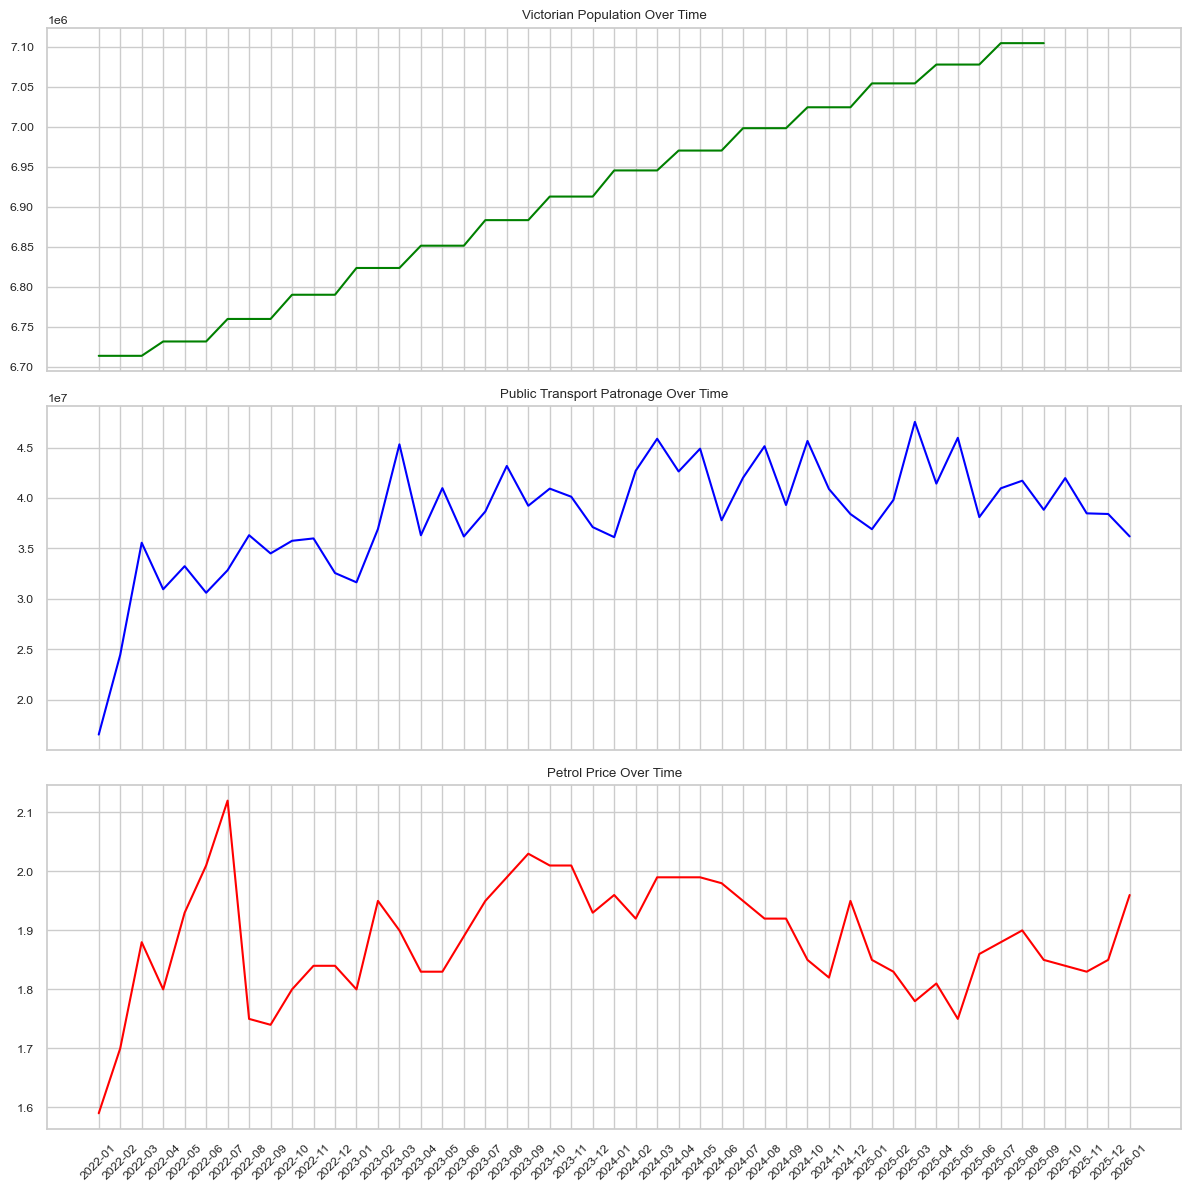

In [21]:
import matplotlib.pyplot as plt

# Create total patronage column if not exists
if 'patronage' not in df.columns:
    patronage_cols = [
        "Metropolitan train", "Metropolitan tram", "Metropolitan bus",
        "Regional train", "Regional coach", "Regional bus"
    ]
    df['patronage'] = df[patronage_cols].sum(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(df['month'], df['population'], color='green')
axes[0].set_title("Victorian Population Over Time")

axes[1].plot(df['month'], df['patronage'], color='blue')
axes[1].set_title("Public Transport Patronage Over Time")

axes[2].plot(df['month'], df['PetrolPrice'], color='red')
axes[2].set_title("Petrol Price Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Victorian Population (green) shows a smooth, consistent upward trend from around 6.72 million to over 7.1 million, with no major disruptions. This provides useful context as a slowly-moving background variable that may partially explain long-run patronage growth.

Public Transport Patronage (purple) starts very low in early 2022 - likely reflecting COVID-19 restrictions - then rises sharply before stabilising at roughly 35-45 million per month from mid-2022 onward. Volatility remains high throughout, which aligns with the seasonal patterns. There is a slight downward drift toward late 2025.

Petrol Price (red) fluctuates considerably, peaking around mid-2022 at $2.10/L before declining and stabilising around $1.80-$2.00. The early peak coincides with the post-COVID fuel price surge. Tracking this alongside patronage is useful as higher petrol prices may incentivise public transport use - worth exploring as a potential predictor variable


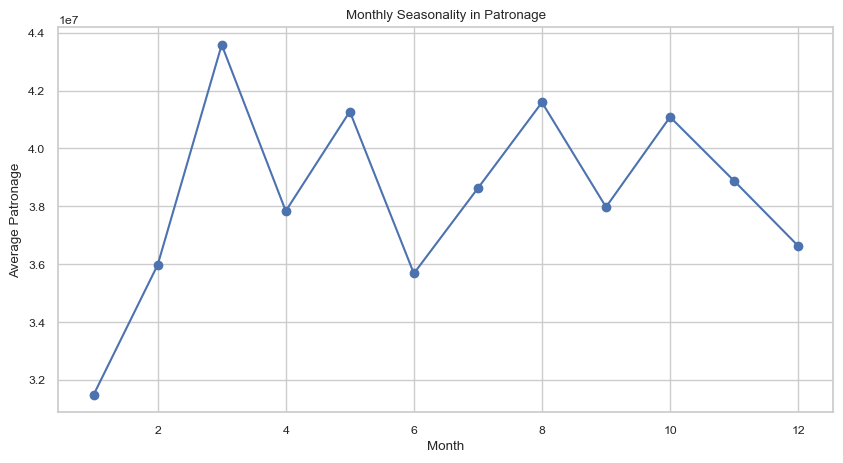

In [23]:
df['month'] = pd.to_datetime(df['month'])
df['month_num'] = df['month'].dt.month

seasonality = df.groupby('month_num')['patronage'].mean()

plt.figure(figsize=(10,5))
plt.plot(seasonality.index, seasonality.values, marker='o')
plt.title("Monthly Seasonality in Patronage")
plt.xlabel("Month")
plt.ylabel("Average Patronage")
plt.grid(True)
plt.show()

To address the earlier issue of noisy public holiday counts, this is a monthly seasonality analysis. This chart shows average patronage by month across all years in the dataset. A clear seasonal pattern is visible - patronage peaks in March (month 3) at around 43.5 million, likely reflecting the start of the academic and work year after summer. A second smaller peak occurs around August-October, while June (month 6) represents the lowest point at roughly 35.8 million, possibly reflecting school holidays and winter travel reductions. January also shows low patronage (31.5 million), consistent with the Australian summer holiday period.

Notably, April (month 4) sits at around 37.9 million - lower than both the preceding March peak and the following May figure - despite containing Easter and ANZAC Day. This suggests that while Easter generates some leisure travel, it does not fully offset the reduction in regular commuter trips during that period